# 🤖 Model Training — Phishing Website Detection

This notebook trains three machine learning models on the UCI Phishing Websites Dataset and saves them as `.pkl` files for use in the backend.

### Models
- **Logistic Regression** — Baseline model
- **Random Forest** — Ensemble model
- **XGBoost** — Boosted model

### Output
Trained models are saved to `../backend/models/` as:
- `model_lr.pkl`
- `model_rf.pkl`
- `model_xgb.pkl`
- `model_best.pkl` (best performing model)

> **Note:** `web_traffic` and `Links_pointing_to_page` are excluded — they require paid APIs not available in real-time. Training uses 28 extractable features.

---

## 📦 Step 1 — Import Libraries

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Create models directory if it doesn't exist
os.makedirs('../backend/models', exist_ok=True)

print('Libraries loaded successfully!')
print('Models will be saved to: ../backend/models/')

Libraries loaded successfully!
Models will be saved to: ../backend/models/


## 📂 Step 2 — Load and Prepare Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/phishing.csv')

# Fix labels: convert -1 (phishing) to 0, keep 1 (legitimate) as 1
df['Result'] = df['Result'].replace(-1, 0)

# Drop features not extractable in real-time
DROPPED_FEATURES = ['web_traffic', 'Links_pointing_to_page']
df = df.drop(columns=DROPPED_FEATURES)

# Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features: {X.shape[1]}')
print(f'Dropped: {DROPPED_FEATURES}')
print(f'Class distribution:')
print(f'  Phishing (0)   : {(y == 0).sum()} samples')
print(f'  Legitimate (1) : {(y == 1).sum()} samples')


Dataset loaded: 11055 rows, 29 columns
Features: 28
Dropped: ['web_traffic', 'Links_pointing_to_page']
Class distribution:
  Phishing (0)   : 4898 samples
  Legitimate (1) : 6157 samples


## ✂️ Step 3 — Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # Ensures class balance in both splits
)

print(f'Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set      : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class distribution in training set:')
print(f'  Phishing (0)   : {(y_train == 0).sum()}')
print(f'  Legitimate (1) : {(y_train == 1).sum()}')
print()
print('Class distribution in test set:')
print(f'  Phishing (0)   : {(y_test == 0).sum()}')
print(f'  Legitimate (1) : {(y_test == 1).sum()}')

Training set  : 7738 samples (70.0%)
Test set      : 3317 samples (30.0%)

Class distribution in training set:
  Phishing (0)   : 3428
  Legitimate (1) : 4310

Class distribution in test set:
  Phishing (0)   : 1470
  Legitimate (1) : 1847


## ⚖️ Step 4 — Feature Scaling (for Logistic Regression)

In [4]:
# Logistic Regression benefits from scaling
# Random Forest and XGBoost do not require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for backend use
joblib.dump(scaler, '../backend/models/scaler.pkl')

print('Scaler fitted and saved to ../backend/models/scaler.pkl')

Scaler fitted and saved to ../backend/models/scaler.pkl


## 🔵 Step 5 — Train Logistic Regression

In [5]:
print('Training Logistic Regression...')
start = time.time()

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs'
)
model_lr.fit(X_train_scaled, y_train)

lr_time = time.time() - start
print(f'Done! Training time: {lr_time:.2f}s')

# Save model
joblib.dump(model_lr, '../backend/models/model_lr.pkl')
print('Saved: ../backend/models/model_lr.pkl')

Training Logistic Regression...
Done! Training time: 0.08s
Saved: ../backend/models/model_lr.pkl


## 🌲 Step 6 — Train Random Forest

In [6]:
print('Training Random Forest...')
start = time.time()

model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)
model_rf.fit(X_train, y_train)

rf_time = time.time() - start
print(f'Done! Training time: {rf_time:.2f}s')

# Save model
joblib.dump(model_rf, '../backend/models/model_rf.pkl')
print('Saved: ../backend/models/model_rf.pkl')

Training Random Forest...
Done! Training time: 0.82s
Saved: ../backend/models/model_rf.pkl


## ⚡ Step 7 — Train XGBoost

In [7]:
print('Training XGBoost...')
start = time.time()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
model_xgb.fit(X_train, y_train)

xgb_time = time.time() - start
print(f'Done! Training time: {xgb_time:.2f}s')

# Save model
joblib.dump(model_xgb, '../backend/models/model_xgb.pkl')
print('Saved: ../backend/models/model_xgb.pkl')

Training XGBoost...
Done! Training time: 2.30s
Saved: ../backend/models/model_xgb.pkl


## 📊 Step 8 — Evaluate All Models on Test Set

In [8]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred),   4),
        'Precision' : round(precision_score(y_test, y_pred),  4),
        'Recall'    : round(recall_score(y_test, y_pred),     4),
        'F1-Score'  : round(f1_score(y_test, y_pred),         4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba),   4),
    }

results = [
    evaluate_model('Logistic Regression', model_lr,  X_test_scaled, y_test),
    evaluate_model('Random Forest',       model_rf,  X_test,        y_test),
    evaluate_model('XGBoost',             model_xgb, X_test,        y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print('Model Performance on Test Set:')
results_df

Model Performance on Test Set:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9201,0.9190,0.9394,0.9290,0.9763
Random Forest,0.9614,0.9643,0.9664,0.9654,0.9949
XGBoost,0.9569,0.9498,0.9740,0.9618,0.9930


## 📉 Step 9 — Confusion Matrices

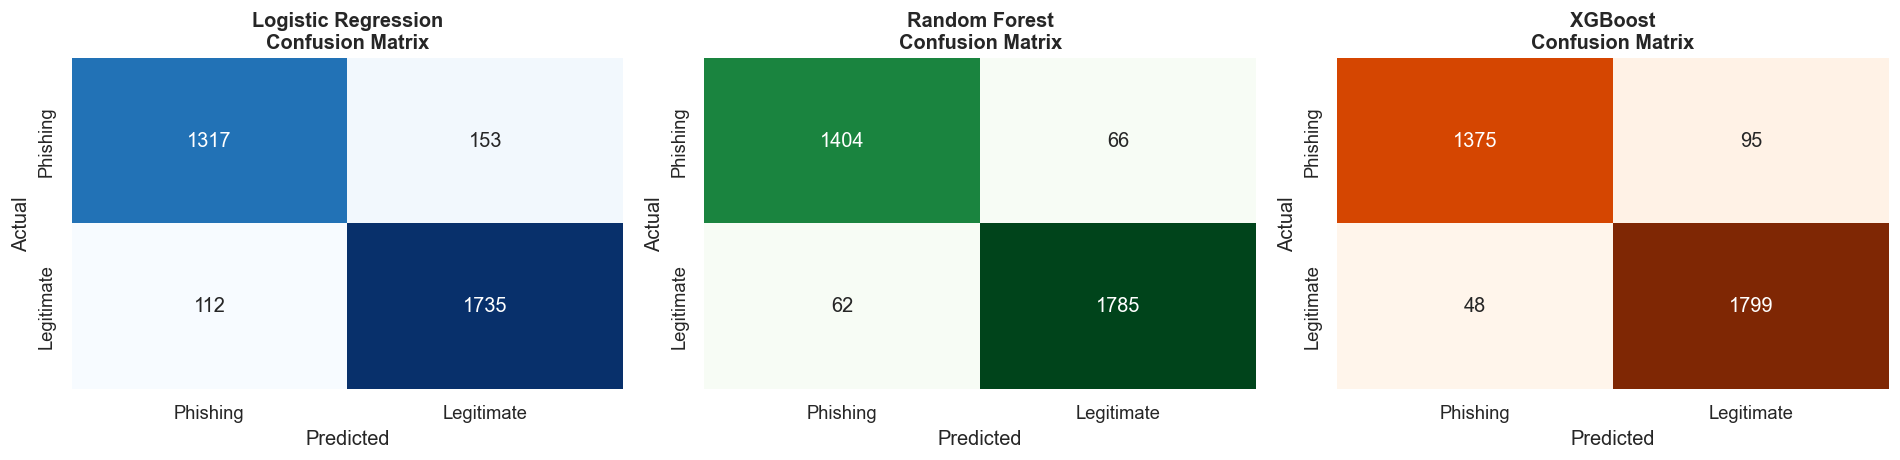

In [9]:
models_eval = {
    'Logistic Regression' : (model_lr,  X_test_scaled),
    'Random Forest'       : (model_rf,  X_test),
    'XGBoost'             : (model_xgb, X_test),
}

cmaps = ['Blues', 'Greens', 'Oranges']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (model, X)), cmap in zip(axes, models_eval.items(), cmaps):
    y_pred = model.predict(X)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        ax=ax, cbar=False,
        xticklabels=['Phishing', 'Legitimate'],
        yticklabels=['Phishing', 'Legitimate']
    )
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 📈 Step 10 — Side-by-Side Metrics Bar Chart

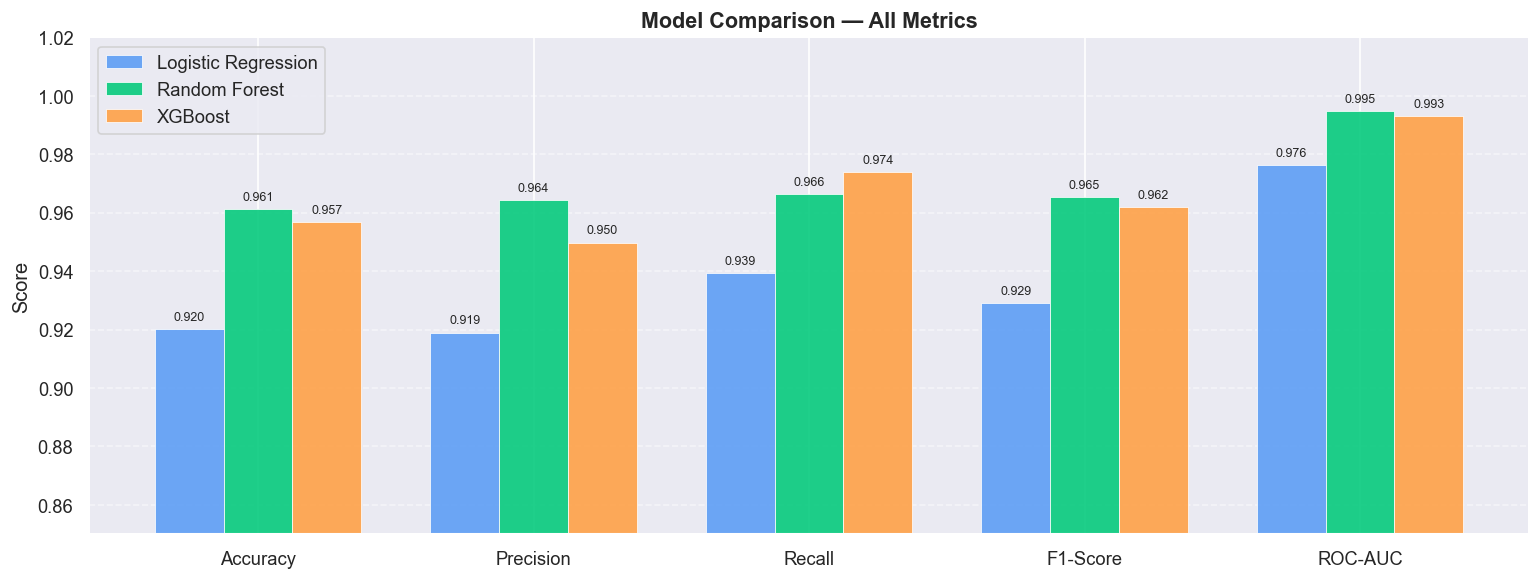

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(metrics))
width  = 0.25
colors = ['#5a9cf5', '#00c97a', '#ff9f43']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model_name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[model_name, metrics].values
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=color, alpha=0.88, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 🔄 Step 11 — Cross-Validation (5-Fold Stratified)

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression' : (model_lr,  X_train_scaled),
    'Random Forest'       : (model_rf,  X_train),
    'XGBoost'             : (model_xgb, X_train),
}

cv_results = {}
for name, (model, X_cv) in cv_models.items():
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  F1 per fold : {[round(s, 4) for s in scores]}')
    print(f'  Mean F1     : {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Logistic Regression:
  F1 per fold : [np.float64(0.9358), np.float64(0.9257), np.float64(0.9258), np.float64(0.9377), np.float64(0.9309)]
  Mean F1     : 0.9312 (+/- 0.0049)

Random Forest:
  F1 per fold : [np.float64(0.9564), np.float64(0.9608), np.float64(0.9573), np.float64(0.9694), np.float64(0.9593)]
  Mean F1     : 0.9606 (+/- 0.0046)

XGBoost:
  F1 per fold : [np.float64(0.9516), np.float64(0.9509), np.float64(0.955), np.float64(0.9615), np.float64(0.9547)]
  Mean F1     : 0.9547 (+/- 0.0038)



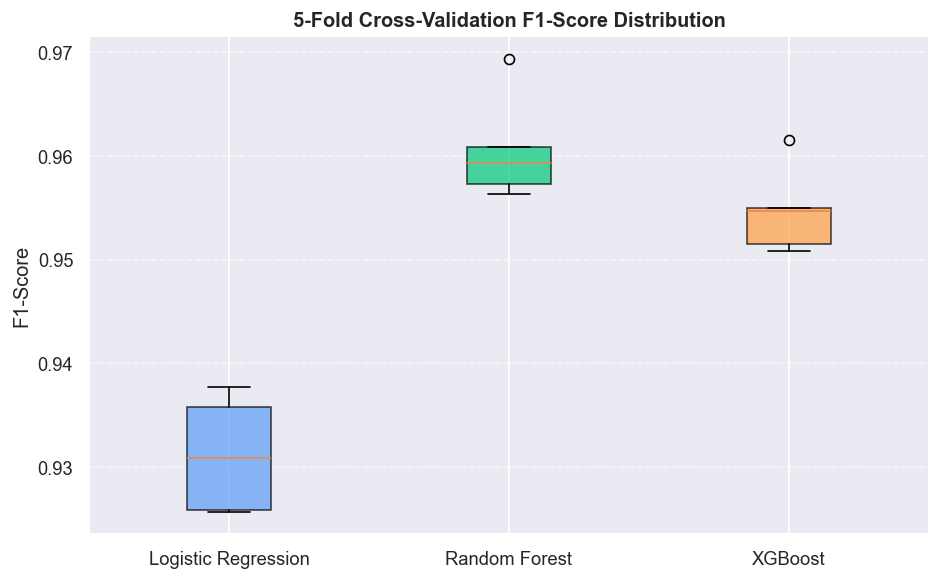

In [12]:
# Cross-validation box plot
fig, ax = plt.subplots(figsize=(8, 5))
cv_data   = list(cv_results.values())
cv_labels = list(cv_results.keys())
colors    = ['#5a9cf5', '#00c97a', '#ff9f43']

bp = ax.boxplot(cv_data, patch_artist=True, notch=False, vert=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(cv_labels)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold Cross-Validation F1-Score Distribution', fontsize=12, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## ⏱️ Step 12 — Training Time Comparison

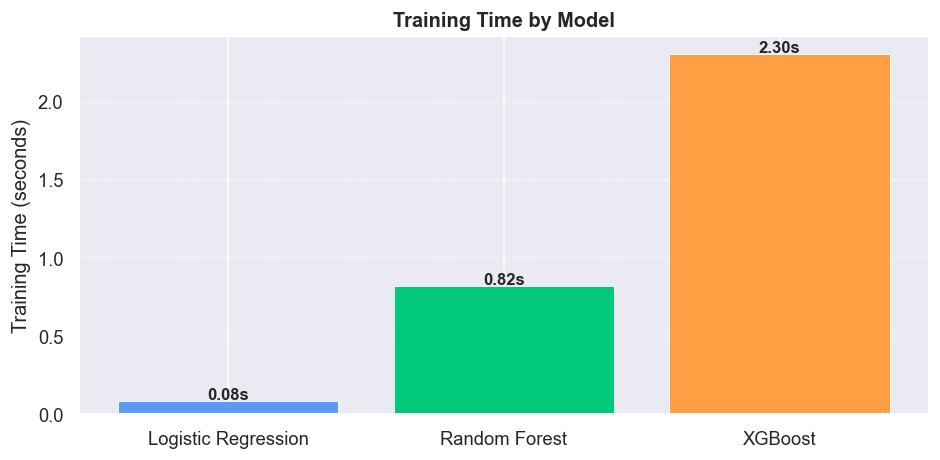

In [13]:
times  = [lr_time, rf_time, xgb_time]
labels = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors = ['#5a9cf5', '#00c97a', '#ff9f43']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, times, color=colors, edgecolor='white', linewidth=0.5)

for bar, t in zip(bars, times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{t:.2f}s',
        ha='center', fontweight='bold', fontsize=10
    )

ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time by Model', fontsize=12, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 🏆 Step 13 — Select and Save Best Model

In [14]:
best_row   = results_df['F1-Score'].idxmax()
best_score = results_df.loc[best_row, 'F1-Score']

best_model_map = {
    'Logistic Regression' : model_lr,
    'Random Forest'       : model_rf,
    'XGBoost'             : model_xgb,
}
best_model = best_model_map[best_row]

joblib.dump(best_model, '../backend/models/model_best.pkl')

print('=' * 45)
print('         TRAINING SUMMARY')
print('=' * 45)
print(f'  Best model : {best_row}')
print(f'  Best F1    : {best_score:.4f}')
print()
print('  Models saved to ../backend/models/:')
print('    model_lr.pkl')
print('    model_rf.pkl')
print('    model_xgb.pkl')
print('    model_best.pkl')
print('    scaler.pkl')
print('=' * 45)
print('  ✅ All models ready for backend use!')
print('=' * 45)

         TRAINING SUMMARY
  Best model : Random Forest
  Best F1    : 0.9654

  Models saved to ../backend/models/:
    model_lr.pkl
    model_rf.pkl
    model_xgb.pkl
    model_best.pkl
    scaler.pkl
  ✅ All models ready for backend use!
